# Runtime Validation For `ModelMaterial`


By Ziyi Xiong 2026/4


This notebook validates the implementation in `optiland.materials.model.ModelMaterial` against the same Sellmeier ground truth and fitting wavelengths used by `02_model_glass_buchdahl_self_consistent.ipynb` and `04_model_glass_buchdahl_ir_anchor.ipynb`.

Two runtime routes are checked:

- **Visible route**: `ModelMaterial(nd, vd, dPgF)`.
- **IR-anchor route**: `ModelMaterial(nd, vd, dPgF, P_ref, lambda_ref=1.55)`.

The validation is run first on the original 17 fitting wavelengths, then on a stratified random wavelength set over the same `[0.36501, 2.3] um` range. The stratified set uses one random sample in each equal-width wavelength interval, so it is random but more evenly distributed than plain random sampling.

In [88]:
from pathlib import Path
import importlib.util
import os
import sys

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import yaml



def find_optiland_custom_root(start=Path.cwd()):
    candidates = []
    for path in [start.resolve(), *start.resolve().parents]:
        candidates.append(path)
        candidates.append(path / "Optiland_Based" / "optiland_custom")
    for path in candidates:
        if (path / "optiland" / "__init__.py").exists():
            return path
    raise RuntimeError("Could not find local optiland package root.")


OPTILAND_CUSTOM_ROOT = find_optiland_custom_root()
if str(OPTILAND_CUSTOM_ROOT) not in sys.path:
    sys.path.insert(0, str(OPTILAND_CUSTOM_ROOT))

from optiland.materials.model import ModelMaterial


plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "Calibri", "DejaVu Sans"],
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "legend.fontsize": 9,
    "figure.dpi": 140,
    "savefig.dpi": 600,
})

ROUTE_STYLE = {
    "visible": {"label": "Visible route", "color": "#1f77b4", "marker": "o"},
    "ir_anchor": {"label": "IR-anchor route", "color": "#b03a2e", "marker": "s"},
}

print("Using optiland root:", OPTILAND_CUSTOM_ROOT)

Using optiland root: D:\Msc.Photonics\Master_Thesis\Optiland_Based\optiland_custom


In [89]:
# Fraunhofer / reference wavelengths in microns.
LAMBDA_d = 0.5875618
LAMBDA_F = 0.4861327
LAMBDA_C = 0.6562725
LAMBDA_g = 0.4358343
LAMBDA_REF = 1.55
VISIBLE_MIN = 0.4
VISIBLE_MAX = 0.7

# Same 17 wavelengths used to fit the visible and IR Buchdahl regressions.
WAVELENGTHS_FIT = np.array([
    0.36501, 0.40466, 0.43583, 0.48613, 0.54607,
    0.58756, 0.58929, 0.6328,  0.64385, 0.65627,
    0.70652, 0.85211, 1.01398, 1.060,   1.52958,
    1.97009, 2.3,
], dtype=np.float64)

WL_MIN = float(WAVELENGTHS_FIT.min())
WL_MAX = float(WAVELENGTHS_FIT.max())


def sellmeier(wavelength, B1, C1, B2, C2, B3, C3):
    wavelength = np.asarray(wavelength, dtype=np.float64)
    wl2 = wavelength**2
    n2 = 1 + B1*wl2/(wl2-C1) + B2*wl2/(wl2-C2) + B3*wl2/(wl2-C3)
    return np.sqrt(n2)


def get_indices(glass, wavelengths):
    c = glass["coeffs"]
    return sellmeier(wavelengths, c["B1"], c["C1"], c["B2"], c["C2"], c["B3"], c["C3"])


def p_ref_from_truth(glass, lambda_ref=LAMBDA_REF):
    n_ref = float(get_indices(glass, np.array([lambda_ref], dtype=np.float64))[0])
    dn_FC = (glass["nd"] - 1.0) / glass["vd"]
    return (n_ref - glass["nd"]) / dn_FC

In [90]:
if "OPTILAND_DB_ROOT" in os.environ:
    DB_ROOT = Path(os.environ["OPTILAND_DB_ROOT"])
else:
    DB_ROOT = OPTILAND_CUSTOM_ROOT / "optiland" / "database"

GLASS_ROOT = DB_ROOT / "data-nk" / "glass"


def extract_glass_record(yml_path: Path):
    with yml_path.open("r", encoding="utf-8") as f:
        doc = yaml.safe_load(f)

    data_blocks = doc.get("DATA") or []
    if not data_blocks:
        return None
    formula = data_blocks[0]
    if formula.get("type") != "formula 2":
        return None

    coeffs = formula.get("coefficients", "").split()
    wavelength_range = formula.get("wavelength_range", "").strip().split()
    if len(coeffs) != 7 or len(wavelength_range) != 2:
        return None

    B1, C1 = float(coeffs[1]), float(coeffs[2])
    B2, C2 = float(coeffs[3]), float(coeffs[4])
    B3, C3 = float(coeffs[5]), float(coeffs[6])

    nd = float(sellmeier(LAMBDA_d, B1, C1, B2, C2, B3, C3))
    nF = float(sellmeier(LAMBDA_F, B1, C1, B2, C2, B3, C3))
    nC = float(sellmeier(LAMBDA_C, B1, C1, B2, C2, B3, C3))
    ng = float(sellmeier(LAMBDA_g, B1, C1, B2, C2, B3, C3))

    dn_FC = nF - nC
    if dn_FC < 1e-12:
        return None

    vd = (nd - 1.0) / dn_FC
    PgF = (ng - nF) / dn_FC
    dPgF = PgF - (0.6438 - 0.001682 * vd)
    specs = doc.get("SPECS", {})

    return {
        "name": yml_path.stem,
        "catalog": yml_path.parent.name,
        "wavelength_range": (float(wavelength_range[0]), float(wavelength_range[1])),
        "coeffs": {"B1": B1, "C1": C1, "B2": B2, "C2": C2, "B3": B3, "C3": C3},
        "nd": float(nd),
        "vd": float(vd),
        "dPgF": float(dPgF),
        "dPgF_stored": specs.get("dPgF"),
    }


def load_glasses(root=GLASS_ROOT):
    records = []
    for yml_path in sorted(root.glob("*/*.yml")):
        try:
            rec = extract_glass_record(yml_path)
        except Exception:
            rec = None
        if rec is not None:
            records.append(rec)
    return records


glasses_all = load_glasses()
glasses = [
    g for g in glasses_all
    if g["wavelength_range"][0] <= WL_MIN
    and g["wavelength_range"][1] >= WL_MAX
]

before_dpgf_filter = len(glasses)
glasses = [
    g for g in glasses
    if g["dPgF_stored"] is None or abs(g["dPgF"] - g["dPgF_stored"]) < 0.05
]

print(f"Loaded {len(glasses_all)} usable formula-2 glasses")
print(f"Validating {len(glasses)} glasses over {WL_MIN:.5f}-{WL_MAX:.1f} um")
print(f"Removed by dPgF sanity filter: {before_dpgf_filter - len(glasses)}")
pd.Series([g["catalog"].lower() for g in glasses]).value_counts().rename("count")

Loaded 640 usable formula-2 glasses
Validating 536 glasses over 0.36501-2.3 um
Removed by dPgF sanity filter: 1


cdgm      240
ohara     177
schott    119
Name: count, dtype: int64

In [91]:
def as_numpy(value):
    return np.asarray(value, dtype=np.float64)


def make_model(glass, route):
    if route == "visible":
        return ModelMaterial(glass["nd"], glass["vd"], glass["dPgF"])
    if route == "ir_anchor":
        return ModelMaterial(
            glass["nd"], glass["vd"], glass["dPgF"],
            P_ref=p_ref_from_truth(glass, LAMBDA_REF),
            lambda_ref=LAMBDA_REF,
        )
    raise ValueError(f"Unknown route: {route}")


def evaluate_route(glasses, wavelengths, route):
    rows = []
    per_wavelength_errors = []
    for glass in glasses:
        truth = get_indices(glass, wavelengths)
        model = make_model(glass, route)
        pred = as_numpy(model.n(wavelengths))
        err = pred - truth
        per_wavelength_errors.append(np.abs(err))
        rows.append({
            "route": route,
            "catalog": glass["catalog"],
            "name": glass["name"],
            "max_abs_err": float(np.max(np.abs(err))),
            "mean_abs_err": float(np.mean(np.abs(err))),
            "rms_err": float(np.sqrt(np.mean(err**2))),
        })
    return pd.DataFrame(rows), np.vstack(per_wavelength_errors)


def summarize_glass_errors(df):
    return df.groupby("route")["max_abs_err"].agg(
        glass_count="count",
        max="max",
        mean="mean",
        median="median",
        p95=lambda s: np.percentile(s, 95),
    )


def summarize_wavelength_errors(errors, wavelengths):
    return pd.DataFrame({
        "wavelength_um": wavelengths,
        "max_abs_err": errors.max(axis=0),
        "mean_abs_err": errors.mean(axis=0),
        "median_abs_err": np.median(errors, axis=0),
    })


VISIBLE_RANGE_HANDLE = Patch(facecolor="#bdbdbd", alpha=0.18, edgecolor="#808080", label="visible range")


def denote_visible_range(ax):
    ax.axvspan(VISIBLE_MIN, VISIBLE_MAX, color="#bdbdbd", alpha=0.18, lw=0.0, zorder=0)
    ax.axvline(VISIBLE_MIN, color="#808080", ls=":", lw=0.8, zorder=1)
    ax.axvline(VISIBLE_MAX, color="#808080", ls=":", lw=0.8, zorder=1)


def legend_with_visible_range(ax, **kwargs):
    handles, labels = ax.get_legend_handles_labels()
    handles.append(VISIBLE_RANGE_HANDLE)
    labels.append("visible range")
    ax.legend(handles, labels, frameon=False, **kwargs)


def plot_route_error_stats(route, wavelengths, errors, title, show_fit_lines=False):
    style = ROUTE_STYLE[route]
    stats = summarize_wavelength_errors(errors, wavelengths)
    fig, ax = plt.subplots(figsize=(6.2, 3.6))
    ax.semilogy(
        stats["wavelength_um"], stats["max_abs_err"],
        color=style["color"], marker=style["marker"], ms=3.2,
        lw=1.4, label="maximum absolute error",
    )
    ax.semilogy(
        stats["wavelength_um"], stats["mean_abs_err"],
        color="#404040", marker="^", ms=3.0,
        lw=1.2, label="mean absolute error",
    )
    if route == "ir_anchor":
        ax.axvline(LAMBDA_REF, color="#606060", ls=":", lw=1.0, label="IR anchor")
    if show_fit_lines:
        ymin, ymax = ax.get_ylim()
        ax.vlines(WAVELENGTHS_FIT, ymin, ymin * (ymax / ymin)**0.04, color="#808080", lw=0.6, alpha=0.7)
        ax.set_ylim(ymin, ymax)
    denote_visible_range(ax)
    ax.set_title(title)
    ax.set_xlabel("Wavelength (um)")
    ax.set_ylabel("Absolute refractive-index error")
    ax.grid(True, which="major", color="#d0d0d0", lw=0.6)
    ax.grid(True, which="minor", color="#e8e8e8", lw=0.4, alpha=0.7)
    legend_with_visible_range(ax, loc="upper right")
    fig.tight_layout()
    return fig, ax, stats

## Original Fitting Wavelengths: Visible Route

This cell compares `ModelMaterial(nd, vd, dPgF).n(wavelength)` to the catalog Sellmeier truth at the exact 17 wavelengths used when fitting the visible-route regression matrix.

In [92]:
fit_visible_results, fit_visible_errors = evaluate_route(glasses, WAVELENGTHS_FIT, "visible")

display(summarize_glass_errors(fit_visible_results))
display(summarize_wavelength_errors(fit_visible_errors, WAVELENGTHS_FIT))
display(fit_visible_results.sort_values("max_abs_err", ascending=False).head(12))

,glass_count,max,mean,median,p95
route,,,,,
visible,536,0.00381,0.00079,0.000572,0.001984


,wavelength_um,max_abs_err,mean_abs_err,median_abs_err
0,0.36501,3.526802e-04,9.867734e-05,9.770645e-05
1,0.40466,4.037527e-04,2.707796e-05,2.370032e-05
2,0.43583,2.673331e-04,1.160945e-04,1.141810e-04
3,0.48613,2.673952e-04,1.161114e-04,1.141974e-04
4,0.54607,1.331408e-05,8.262020e-06,8.223522e-06
5,0.58756,3.816037e-09,1.166291e-09,1.151913e-09
6,0.58929,3.778936e-06,1.177063e-06,1.162502e-06
7,0.63280,1.574760e-04,6.348556e-05,6.242197e-05
8,0.64385,2.081189e-04,8.711451e-05,8.554996e-05
9,0.65627,2.673678e-04,1.161004e-04,1.141866e-04


,route,catalog,name,max_abs_err,mean_abs_err,rms_err
384,visible,ohara,S-NBH56,0.003810,0.000579,0.001212
228,visible,cdgm,H-ZLAF76,0.003751,0.000542,0.001142
279,visible,ohara,LAM7,0.003358,0.000566,0.001064
261,visible,ohara,L-LAH87,0.002743,0.000491,0.000880
425,visible,schott,KZFS12,0.002740,0.000431,0.000846
377,visible,ohara,S-LAM66,0.002672,0.000421,0.000835
119,visible,cdgm,H-LAF3B,0.002597,0.000450,0.000825
276,visible,ohara,LAM58,0.002542,0.000434,0.000803
371,visible,ohara,S-LAM54,0.002528,0.000415,0.000793
350,visible,ohara,S-LAH71,0.002516,0.000460,0.000815


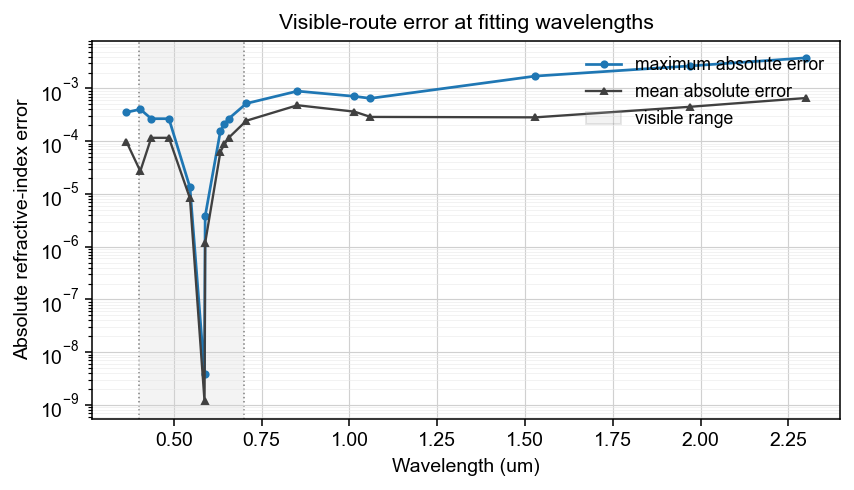

In [93]:
fig, ax, fit_visible_stats = plot_route_error_stats(
    "visible", WAVELENGTHS_FIT, fit_visible_errors,
    "Visible-route error at fitting wavelengths",
)
plt.show()

## Original Fitting Wavelengths: IR-Anchor Route

This cell compares `ModelMaterial(nd, vd, dPgF, P_ref, lambda_ref=1.55).n(wavelength)` to the catalog Sellmeier truth at the same 17 fitting wavelengths.

In [94]:
fit_ir_results, fit_ir_errors = evaluate_route(glasses, WAVELENGTHS_FIT, "ir_anchor")

display(summarize_glass_errors(fit_ir_results))
display(summarize_wavelength_errors(fit_ir_errors, WAVELENGTHS_FIT))
display(fit_ir_results.sort_values("max_abs_err", ascending=False).head(12))

,glass_count,max,mean,median,p95
route,,,,,
ir_anchor,536,0.001742,0.000219,0.000201,0.000324


,wavelength_um,max_abs_err,mean_abs_err,median_abs_err
0,0.36501,3.550313e-04,3.353752e-05,2.608306e-05
1,0.40466,5.081680e-04,8.606156e-06,3.598306e-06
2,0.43583,4.677909e-04,2.428196e-05,1.849334e-05
3,0.48613,4.678883e-04,2.428544e-05,1.849558e-05
4,0.54607,1.026524e-05,1.820985e-06,1.787382e-06
5,0.58756,6.623290e-09,2.450042e-10,1.489082e-10
6,0.58929,6.568131e-06,2.473240e-07,1.523363e-07
7,0.63280,2.769965e-04,1.333220e-05,9.768747e-06
8,0.64385,3.654748e-04,1.826529e-05,1.368340e-05
9,0.65627,4.678422e-04,2.428317e-05,1.849388e-05


,route,catalog,name,max_abs_err,mean_abs_err,rms_err
293,ir_anchor,ohara,PBM8Y,0.001742,0.000147,0.000432
252,ir_anchor,ohara,L-BBH1,0.001328,0.000419,0.000554
290,ir_anchor,ohara,PBM18Y,0.001174,0.000100,0.000289
388,ir_anchor,ohara,S-NPH3,0.001001,0.000291,0.000392
286,ir_anchor,ohara,PBL25Y,0.000974,0.000085,0.000240
288,ir_anchor,ohara,PBL26Y,0.000937,0.000081,0.000230
253,ir_anchor,ohara,L-BBH2,0.000921,0.000287,0.000381
291,ir_anchor,ohara,PBM2Y,0.000650,0.000063,0.000162
389,ir_anchor,ohara,S-NPH4,0.000629,0.000158,0.000226
241,ir_anchor,ohara,BAL15Y,0.000628,0.000054,0.000154


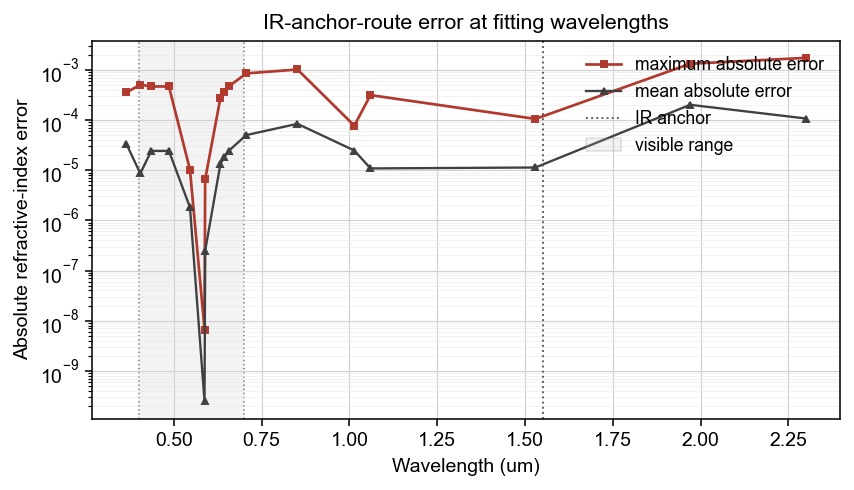

In [95]:
fig, ax, fit_ir_stats = plot_route_error_stats(
    "ir_anchor", WAVELENGTHS_FIT, fit_ir_errors,
    "IR-anchor-route error at fitting wavelengths",
)
plt.show()

## Stratified Random Wavelength Validation: Visible Route

The validation set below divides the fitting range into 20 equal-width intervals and draws one random wavelength from each interval. No endpoint or `lambda_ref = 1.55 um` wavelength is forced into the validation set.

In [96]:
rng = np.random.default_rng(20260430)
n_random_wavelengths = 20
edges = np.linspace(WL_MIN, WL_MAX, n_random_wavelengths + 1)
u = rng.random(n_random_wavelengths)
WAVELENGTHS_RANDOM_STRATIFIED = np.sort(edges[:-1] + u * np.diff(edges))

print(f"Stratified random wavelengths: {len(WAVELENGTHS_RANDOM_STRATIFIED)} samples")
print(f"range: {WAVELENGTHS_RANDOM_STRATIFIED.min():.5f}-{WAVELENGTHS_RANDOM_STRATIFIED.max():.5f} um")
print(f"largest gap: {np.diff(WAVELENGTHS_RANDOM_STRATIFIED).max():.5f} um")

random_visible_results, random_visible_errors = evaluate_route(
    glasses, WAVELENGTHS_RANDOM_STRATIFIED, "visible"
)

display(summarize_glass_errors(random_visible_results))
display(random_visible_results.sort_values("max_abs_err", ascending=False).head(12))

Stratified random wavelengths: 20 samples
range: 0.42006-2.25524 um
largest gap: 0.14985 um


,glass_count,max,mean,median,p95
route,,,,,
visible,536,0.003614,0.000764,0.000564,0.001895


,route,catalog,name,max_abs_err,mean_abs_err,rms_err
384,visible,ohara,S-NBH56,0.003614,0.001336,0.001766
228,visible,cdgm,H-ZLAF76,0.003510,0.001181,0.001584
279,visible,ohara,LAM7,0.003248,0.001135,0.001482
261,visible,ohara,L-LAH87,0.002666,0.000928,0.001204
425,visible,schott,KZFS12,0.002544,0.000906,0.001175
119,visible,cdgm,H-LAF3B,0.002517,0.000865,0.001129
377,visible,ohara,S-LAM66,0.002497,0.000905,0.001175
276,visible,ohara,LAM58,0.002461,0.000838,0.001100
350,visible,ohara,S-LAH71,0.002445,0.000873,0.001119
371,visible,ohara,S-LAM54,0.002351,0.000866,0.001112


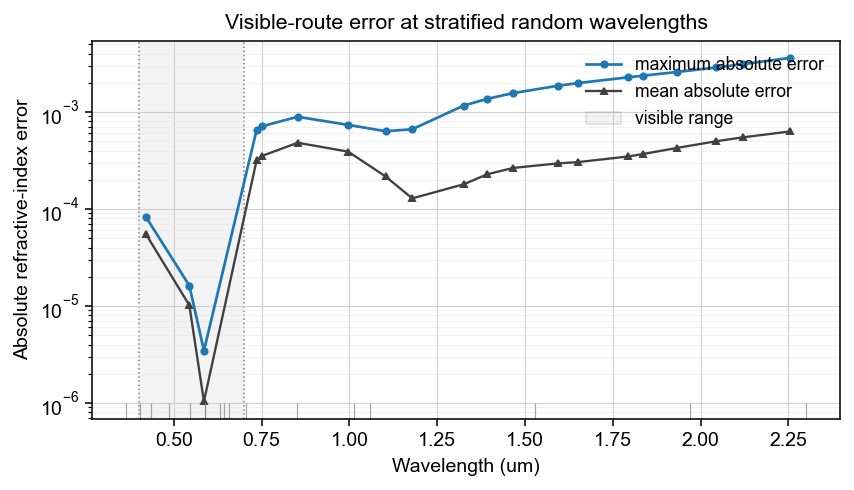

In [97]:
fig, ax, random_visible_stats = plot_route_error_stats(
    "visible", WAVELENGTHS_RANDOM_STRATIFIED, random_visible_errors,
    "Visible-route error at stratified random wavelengths",
    show_fit_lines=True,
)
plt.show()

## Stratified Random Wavelength Validation: IR-Anchor Route

The IR route is evaluated on the same stratified random wavelength set. The vertical reference line marks the IR partial-dispersion anchor at `1.55 um`.

In [98]:
random_ir_results, random_ir_errors = evaluate_route(
    glasses, WAVELENGTHS_RANDOM_STRATIFIED, "ir_anchor"
)

display(summarize_glass_errors(random_ir_results))
display(random_ir_results.sort_values("max_abs_err", ascending=False).head(12))

,glass_count,max,mean,median,p95
route,,,,,
ir_anchor,536,0.00145,0.000212,0.000197,0.000321


,route,catalog,name,max_abs_err,mean_abs_err,rms_err
293,ir_anchor,ohara,PBM8Y,0.001450,0.000180,0.000392
252,ir_anchor,ohara,L-BBH1,0.001344,0.000669,0.000802
388,ir_anchor,ohara,S-NPH3,0.001010,0.000482,0.000579
290,ir_anchor,ohara,PBM18Y,0.000951,0.000111,0.000246
253,ir_anchor,ohara,L-BBH2,0.000935,0.000463,0.000550
286,ir_anchor,ohara,PBL25Y,0.000785,0.000093,0.000201
288,ir_anchor,ohara,PBL26Y,0.000756,0.000090,0.000195
389,ir_anchor,ohara,S-NPH4,0.000630,0.000286,0.000349
284,ir_anchor,ohara,PBH71,0.000502,0.000225,0.000274
241,ir_anchor,ohara,BAL15Y,0.000499,0.000060,0.000126


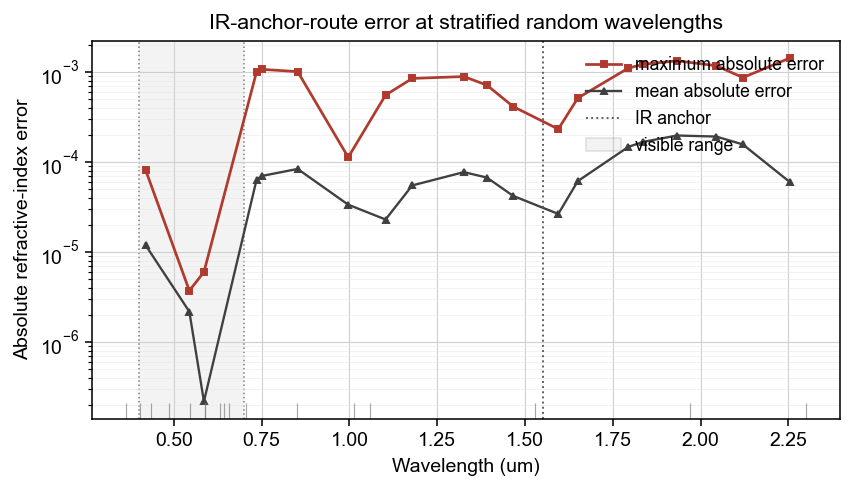

In [99]:
fig, ax, random_ir_stats = plot_route_error_stats(
    "ir_anchor", WAVELENGTHS_RANDOM_STRATIFIED, random_ir_errors,
    "IR-anchor-route error at stratified random wavelengths",
    show_fit_lines=True,
)
plt.show()

## Visible Versus IR-Anchor Error Comparison

The next figures overlay the visible-route and IR-anchor-route errors for the original fitting wavelengths and for the stratified random wavelength set. This directly shows the runtime improvement from adding the IR partial-dispersion anchor.

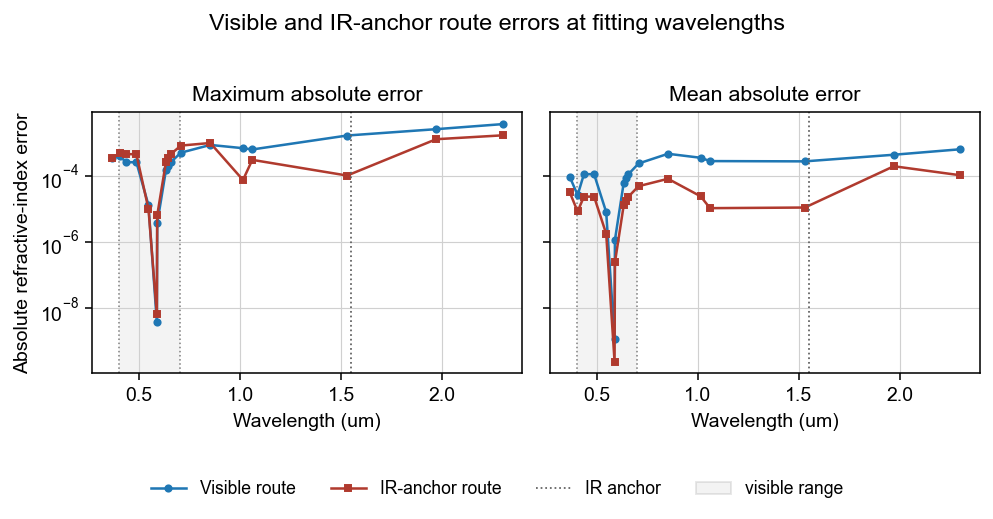

In [100]:
def plot_route_comparison(wavelengths, visible_errors, ir_errors, title):
    visible_stats = summarize_wavelength_errors(visible_errors, wavelengths)
    ir_stats = summarize_wavelength_errors(ir_errors, wavelengths)

    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.4), sharey=True)
    for ax, stat_name, label in [
        (axes[0], "max_abs_err", "Maximum absolute error"),
        (axes[1], "mean_abs_err", "Mean absolute error"),
    ]:
        ax.semilogy(
            visible_stats["wavelength_um"], visible_stats[stat_name],
            color=ROUTE_STYLE["visible"]["color"], marker=ROUTE_STYLE["visible"]["marker"],
            ms=3.2, lw=1.3, label=ROUTE_STYLE["visible"]["label"],
        )
        ax.semilogy(
            ir_stats["wavelength_um"], ir_stats[stat_name],
            color=ROUTE_STYLE["ir_anchor"]["color"], marker=ROUTE_STYLE["ir_anchor"]["marker"],
            ms=3.2, lw=1.3, label=ROUTE_STYLE["ir_anchor"]["label"],
        )
        ax.axvline(LAMBDA_REF, color="#606060", ls=":", lw=0.9)
        denote_visible_range(ax)
        ax.set_title(label)
        ax.set_xlabel("Wavelength (um)")
        ax.grid(True, which="major", color="#d0d0d0", lw=0.6)
        ax.grid(True, which="minor", color="#e8e8e8", lw=0.4, alpha=0.7)
    axes[0].set_ylabel("Absolute refractive-index error")
    comparison_handles = [
        Line2D([0], [0], color=ROUTE_STYLE["visible"]["color"], marker=ROUTE_STYLE["visible"]["marker"], lw=1.3, ms=3.2, label=ROUTE_STYLE["visible"]["label"]),
        Line2D([0], [0], color=ROUTE_STYLE["ir_anchor"]["color"], marker=ROUTE_STYLE["ir_anchor"]["marker"], lw=1.3, ms=3.2, label=ROUTE_STYLE["ir_anchor"]["label"]),
        Line2D([0], [0], color="#606060", ls=":", lw=0.9, label="IR anchor"),
        VISIBLE_RANGE_HANDLE,
    ]
    fig.legend(handles=comparison_handles, loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.03))
    fig.suptitle(title, y=1.02)
    fig.tight_layout(rect=(0, 0.10, 1, 1))
    return fig, axes


fig, axes = plot_route_comparison(
    WAVELENGTHS_FIT, fit_visible_errors, fit_ir_errors,
    "Visible and IR-anchor route errors at fitting wavelengths",
)
plt.show()

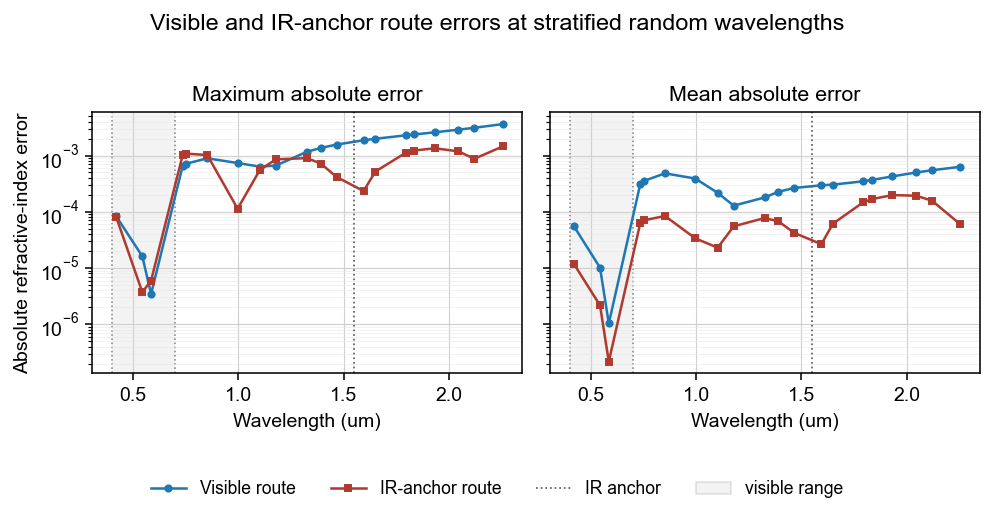

In [101]:
fig, axes = plot_route_comparison(
    WAVELENGTHS_RANDOM_STRATIFIED, random_visible_errors, random_ir_errors,
    "Visible and IR-anchor route errors at stratified random wavelengths",
)
plt.show()

## Runtime Nominal/Perturbed Glass Curves

This section repeats the nominal/perturbed descriptor comparison from notebook 04 using the runtime `ModelMaterial` implementation only. The visible and IR routes therefore use the runtime regression matrices and runtime alpha values defined in `model.py`. The IR perturbation keeps the nominal relative partial dispersion `P_ref` fixed while changing `nd` and `Vd`, matching the model-glass behavior described in notebook 04.

The selected glasses are CDGM `H-LAF3B`, CDGM `H-ZK9B`, OHARA `S-FPL53`, and SCHOTT `N-BK7`.

In [102]:
def find_filtered_glass(catalog, name):
    matches = [
        g for g in glasses
        if g["catalog"].lower() == catalog.lower() and g["name"].upper() == name.upper()
    ]
    if not matches:
        raise ValueError(f"Glass not found in filtered set: {catalog}/{name}")
    return matches[0]


SELECTED_GLASS_KEYS = [
    ("cdgm", "H-LAF3B"),
    ("cdgm", "H-ZK9B"),
    ("ohara", "S-FPL53"),
    ("schott", "N-BK7"),
]

selected_glasses = [find_filtered_glass(catalog, name) for catalog, name in SELECTED_GLASS_KEYS]
wl_curve = np.linspace(WL_MIN, WL_MAX, 500)

PERTURB_ND = 5.0e-4
PERTURB_VD_SCALE = 1.005


def make_runtime_model_from_descriptors(nd, vd, dPgF, route, p_ref=None):
    if route == "visible":
        return ModelMaterial(nd, vd, dPgF)
    if route == "ir_anchor":
        return ModelMaterial(nd, vd, dPgF, P_ref=p_ref, lambda_ref=LAMBDA_REF)
    raise ValueError(f"Unknown route: {route}")


def nominal_and_perturbed_models(glass, route):
    p_ref = p_ref_from_truth(glass, LAMBDA_REF) if route == "ir_anchor" else None
    nominal = make_runtime_model_from_descriptors(
        glass["nd"], glass["vd"], glass["dPgF"], route, p_ref=p_ref
    )
    perturbed = make_runtime_model_from_descriptors(
        glass["nd"] + PERTURB_ND,
        glass["vd"] * PERTURB_VD_SCALE,
        glass["dPgF"],
        route,
        p_ref=p_ref,
    )
    return nominal, perturbed


perturbation_rows = []
for glass in selected_glasses:
    perturbation_rows.append({
        "catalog": glass["catalog"],
        "name": glass["name"],
        "nd_nominal": glass["nd"],
        "vd_nominal": glass["vd"],
        "dPgF_nominal": glass["dPgF"],
        "P_ref_nominal": p_ref_from_truth(glass, LAMBDA_REF),
        "nd_perturbed": glass["nd"] + PERTURB_ND,
        "vd_perturbed": glass["vd"] * PERTURB_VD_SCALE,
    })

display(pd.DataFrame(perturbation_rows))

,catalog,name,nd_nominal,vd_nominal,dPgF_nominal,P_ref_nominal,nd_perturbed,vd_perturbed
0,cdgm,H-LAF3B,1.74400,44.900027,-0.003174,-1.536190,1.74450,45.124527
1,cdgm,H-ZK9B,1.62041,60.339343,-0.000976,-1.866565,1.62091,60.641040
2,ohara,S-FPL53,1.43875,94.946025,0.050204,-1.850896,1.43925,95.420755
3,schott,N-BK7,1.51680,64.167336,-0.000940,-2.004980,1.51730,64.488173


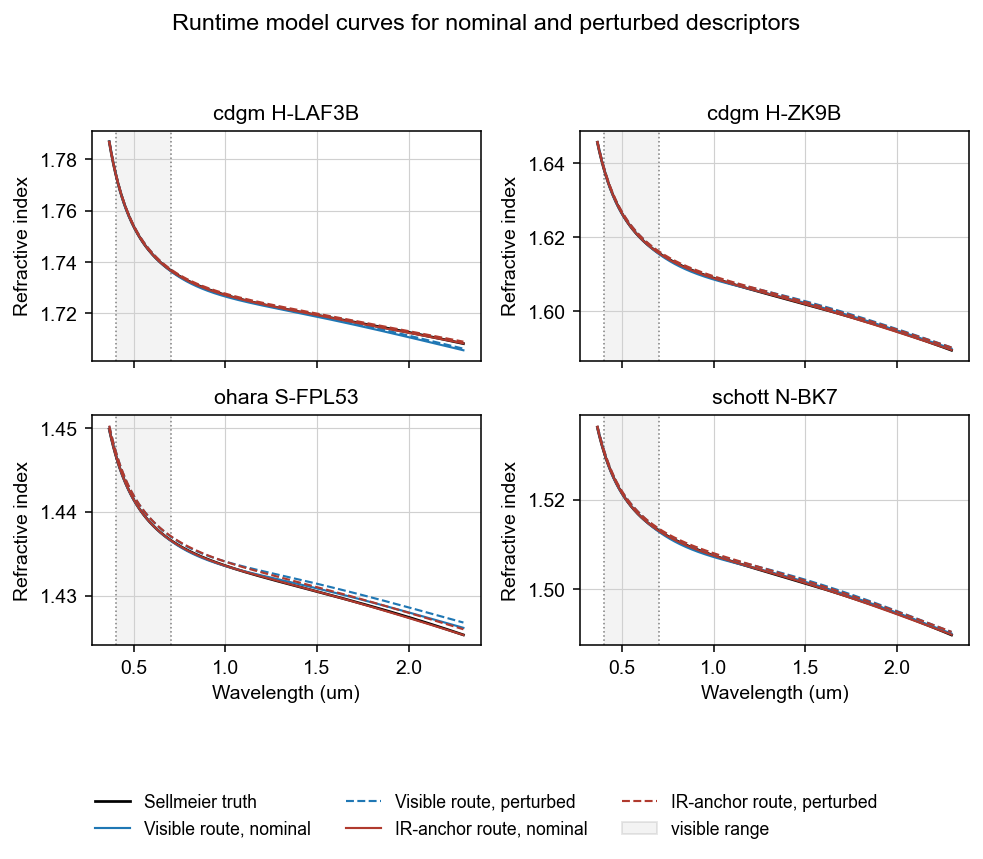

In [103]:
curve_specs = [
    ("visible", "nominal", "#1f77b4", "-"),
    ("visible", "perturbed", "#1f77b4", "--"),
    ("ir_anchor", "nominal", "#b03a2e", "-"),
    ("ir_anchor", "perturbed", "#b03a2e", "--"),
]

fig, axes = plt.subplots(2, 2, figsize=(7.2, 5.8), sharex=True)
for ax, glass in zip(axes.ravel(), selected_glasses):
    n_truth = get_indices(glass, wl_curve)
    ax.plot(wl_curve, n_truth, color="black", lw=1.4, label="Sellmeier truth")
    for route, state, color, linestyle in curve_specs:
        nominal, perturbed = nominal_and_perturbed_models(glass, route)
        model = nominal if state == "nominal" else perturbed
        label = f"{ROUTE_STYLE[route]['label']}, {state}"
        ax.plot(wl_curve, as_numpy(model.n(wl_curve)), color=color, ls=linestyle, lw=1.1, label=label)
    ax.set_title(f"{glass['catalog']} {glass['name']}")
    ax.set_ylabel("Refractive index")
    denote_visible_range(ax)
    ax.grid(True, which="major", color="#d0d0d0", lw=0.6)
    ax.grid(True, which="minor", color="#e8e8e8", lw=0.4, alpha=0.7)

for ax in axes[-1, :]:
    ax.set_xlabel("Wavelength (um)")

handles, labels = axes[0, 0].get_legend_handles_labels()
handles.append(VISIBLE_RANGE_HANDLE)
labels.append("visible range")
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.04))
fig.suptitle("Runtime model curves for nominal and perturbed descriptors", y=0.995)
fig.tight_layout(rect=(0, 0.12, 1, 0.96))
plt.show()

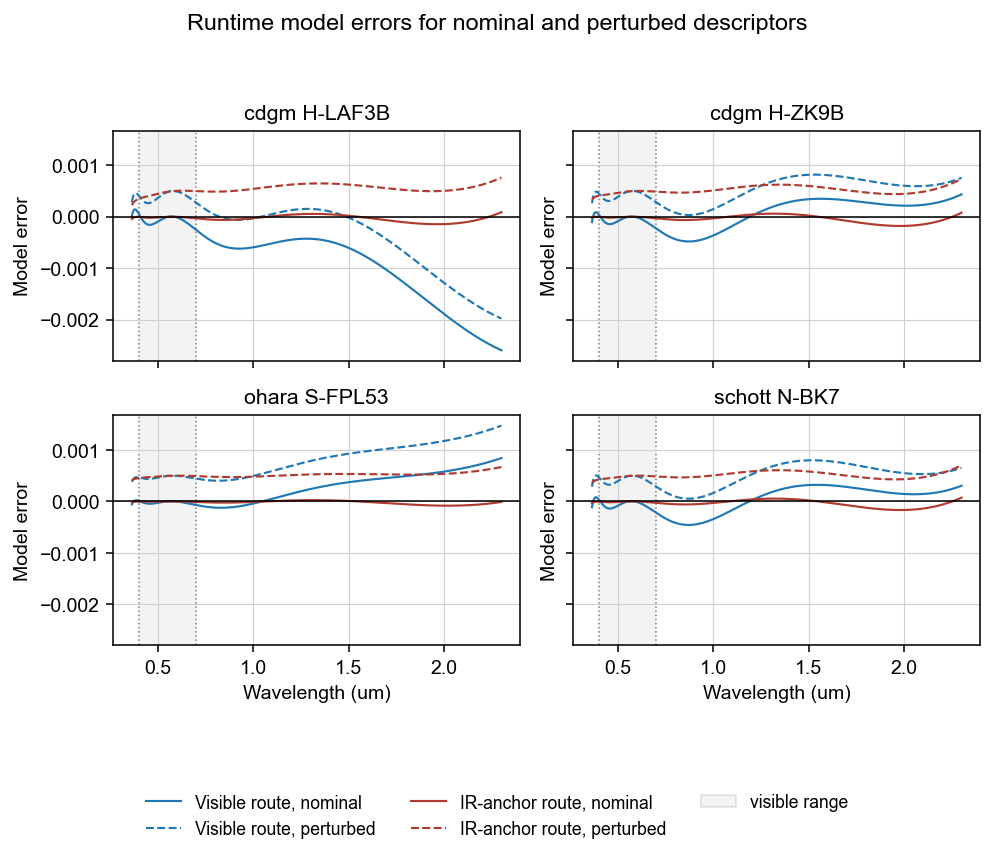

In [104]:
fig, axes = plt.subplots(2, 2, figsize=(7.2, 5.8), sharex=True, sharey=True)
for ax, glass in zip(axes.ravel(), selected_glasses):
    n_truth = get_indices(glass, wl_curve)
    for route, state, color, linestyle in curve_specs:
        nominal, perturbed = nominal_and_perturbed_models(glass, route)
        model = nominal if state == "nominal" else perturbed
        err = as_numpy(model.n(wl_curve)) - n_truth
        label = f"{ROUTE_STYLE[route]['label']}, {state}"
        ax.plot(wl_curve, err, color=color, ls=linestyle, lw=1.1, label=label)
    ax.axhline(0.0, color="black", lw=0.8)
    ax.set_title(f"{glass['catalog']} {glass['name']}")
    ax.set_ylabel("Model error")
    denote_visible_range(ax)
    ax.grid(True, which="major", color="#d0d0d0", lw=0.6)
    ax.grid(True, which="minor", color="#e8e8e8", lw=0.4, alpha=0.7)

for ax in axes[-1, :]:
    ax.set_xlabel("Wavelength (um)")

handles, labels = axes[0, 0].get_legend_handles_labels()
handles.append(VISIBLE_RANGE_HANDLE)
labels.append("visible range")
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.04))
fig.suptitle("Runtime model errors for nominal and perturbed descriptors", y=0.995)
fig.tight_layout(rect=(0, 0.12, 1, 0.96))
plt.show()

## Anchor Self-Check

The visible route should preserve `nd`, `Vd`, and `dPgF`. The IR route should also preserve the relative IR partial dispersion `P_ref` at `lambda_ref = 1.55 um`.

In [105]:
def anchor_errors(glasses, route):
    rows = []
    for glass in glasses:
        model = make_model(glass, route)
        row = {
            "route": route,
            "catalog": glass["catalog"],
            "name": glass["name"],
            "nd_err": abs(float(model.n(LAMBDA_d)) - glass["nd"]),
            "vd_err": abs(float(model.abbe()) - glass["vd"]),
            "dPgF_err": abs(float(model.dPgF()) - glass["dPgF"]),
        }
        if route == "ir_anchor":
            row["P_ref_err"] = abs(float(model.P_ref(LAMBDA_REF)) - p_ref_from_truth(glass, LAMBDA_REF))
        rows.append(row)
    return pd.DataFrame(rows)


anchor_df = pd.concat([
    anchor_errors(glasses, "visible"),
    anchor_errors(glasses, "ir_anchor"),
], ignore_index=True)

display(anchor_df.groupby("route").max(numeric_only=True))
display(anchor_df.sort_values(["dPgF_err", "vd_err"], ascending=False).head(12))

,nd_err,vd_err,dPgF_err,P_ref_err
route,,,,
ir_anchor,0.0,9.066525e-12,1.622591e-13,6.394885e-14
visible,0.0,5.243805e-12,9.825474e-14,NaN


,route,catalog,name,nd_err,vd_err,dPgF_err,P_ref_err
866,ir_anchor,ohara,S-FPL55,0.0,9.066525e-12,1.622591e-13,0.000000e+00
694,ir_anchor,cdgm,H-QK1,0.0,4.220624e-12,1.039169e-13,3.153033e-14
787,ir_anchor,ohara,L-BAL35,0.0,2.820855e-12,9.869883e-14,0.000000e+00
28,visible,cdgm,D-PK3-25,0.0,4.192202e-12,9.825474e-14,NaN
564,ir_anchor,cdgm,D-PK3-25,0.0,4.177991e-12,9.825474e-14,2.975398e-14
537,ir_anchor,cdgm,D-FK61,0.0,2.984279e-12,9.758860e-14,0.000000e+00
96,visible,cdgm,H-FK61,0.0,2.970069e-12,9.758860e-14,NaN
433,visible,schott,LITHOTEC-CAF2,0.0,0.000000e+00,9.747758e-14,NaN
979,ir_anchor,schott,N-BAK4,0.0,2.444267e-12,9.359180e-14,0.000000e+00
980,ir_anchor,schott,N-BAK4HT,0.0,2.444267e-12,9.359180e-14,0.000000e+00
